In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, Dataset,random_split
from torchvision.datasets import DatasetFolder
from sklearn.model_selection import train_test_split
import random
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import os
import pandas as pd

epochs=20
batch_size=16
lr=4e-3
spf = 0.1  # reciprocal of frames per second
fc_hidden=128
accumulation_steps = 8
eps = 1e-6

In [28]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [30]:
raw_df = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_merged_data.csv")

KeyboardInterrupt: 

In [ ]:
# Max length to be pad sequences to
max_output_length = raw_df['timestamp'].max()//spf

In [ ]:
train_users, test_users = train_test_split(raw_df['user_id'].unique(), test_size=0.2, random_state=42)
train_df, test_df = raw_df[raw_df['user_id'].isin(train_users)], raw_df[raw_df['user_id'].isin(test_users)]

train_df.set_index(['user_id','emotion'], inplace=True)
test_df.set_index(['user_id','emotion'], inplace=True)

In [ ]:
def process_input_sequence(sequence):
    mask = ~sequence.drop(columns=['timestamp']).isna().values  # Create a mask for non-null values

    sensor_cols = sequence.columns.drop("timestamp")
    mean_values = sequence[sensor_cols].mean()
    std_values = sequence[sensor_cols].std()

    # Center the sensor values by subtracting the mean and scaling by the standard deviation
    sequence[sensor_cols]-= mean_values
    sequence[sensor_cols]/= (std_values + eps)

    sequence = sequence.fillna(0).values  # Fill NaN values with 0 for processing
    
    # Concatenate and convert to torch tensor
    sequence = np.concatenate([sequence, mask], axis=-1)
    tensor_sequence = torch.tensor(sequence, dtype=torch.float32)
    
    return tensor_sequence, mean_values, std_values

def process_target_sequence(sequence, mean_values, std_values):
    timestamp = sequence['timestamp'].values  # Extract timestamp values
    sequence = sequence.drop(columns=['timestamp'])

    # Center the sensor values by subtracting the mean and scaling by the standard deviation
    sequence-= mean_values
    sequence/= (std_values + eps)

    mask = ~sequence.isna().values  # Create a mask for non-null values
    sequence = sequence.fillna(0).values  # Fill NaN values with 0 for processing
    
    # Convert to torch tensor
    tensor_sequence = torch.tensor(sequence, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.bool)
    timestamp = torch.tensor(timestamp, dtype=torch.float32)
    
    return timestamp, tensor_sequence, mask

In [ ]:
class RadarSequenceDataset(Dataset):
    def __init__(self, df, test_size=0.2, random_state=42):
        """
        Args:
            df: DataFrame with radar data
            test_size: Proportion of data for testing
            random_state: Random seed for reproducibility
        """
        # Split data
        self.df = df
        self.experiments = df.index.unique()
        self.test_size = test_size
        self.random_state = random_state
    
    def __len__(self):
        return len(self.experiments)
    
    def __getitem__(self, idx):
        experiment = self.experiments[idx]
        experiment_data = self.df.loc[experiment]

        # Split into input and target sequences
        input_sequence, target_sequence = train_test_split(experiment_data, test_size=self.test_size, random_state=self.random_state)
        
        
        # Process using existing function
        input_sequence, mean_values, std_values = process_input_sequence(input_sequence)
        timestamp, target_sequence, mask = process_target_sequence(target_sequence, mean_values, std_values)
        
        return input_sequence, timestamp, target_sequence, mask


# Create train and test datasets
train_dataset = RadarSequenceDataset(train_df, test_size=0.2, random_state=42)
test_dataset = RadarSequenceDataset(test_df, test_size=0.2, random_state=42)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [ ]:
for input_sequence, timestamp, target_sequence, mask in train_loader:
    print(input_sequence.shape, target_sequence.shape)
    break

torch.Size([1, 2839, 79]) torch.Size([1, 710, 39])


In [ ]:
class InterpolationAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim=79,
        hidden_dim=128,
        latent_dim=64,
        output_dim=39
    ):
        super().__init__()

        self.output_dim = output_dim

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        #self.decoder = nn.LSTM(
        #    input_size=hidden_dim*2,
        #    hidden_size=latent_dim,
        #    batch_first=True,
        #    bidirectional=False
        #)

        self.interpolator = nn.Sequential(
            nn.Linear(hidden_dim*2 + 1, 256),
            nn.ReLU(),

            #nn.Linear(256, 256),
            #nn.ReLU(),

            nn.Linear(256, self.output_dim),
            nn.Tanh(),
        )

    def encode(self, x):
        return self.encoder(x)
    
    def interpolate(self, hidden_state, t_query):
        z = hidden_state.unsqueeze(1).repeat(1, t_query.size(1), 1)
        #print(f"Shape of z: {z.shape}, Shape of t_query: {t_query.shape}")
        dec_in = torch.cat([z, t_query], dim=-1)
        out = self.interpolator(dec_in)
        return out

    def forward(self, x, t_query):
        hidden_sequence, _ = self.encode(x)
        hidden_state = hidden_sequence[:,-1]  # Use the last hidden state for interpolation
        out = self.interpolate(hidden_state, t_query.unsqueeze(-1))

        return out

In [ ]:
model = InterpolationAutoencoder()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=4e-3
)

def criterion(predictions, targets, mask):
    loss = ((predictions[mask] - targets[mask])**2 ).sum() / (mask.sum() + eps)
    return loss

In [ ]:
train_loss_history = []
test_loss_history = []
print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for i, (input_sequence, timestamp, target_sequence, mask) in enumerate(pbar):
        
        pred = model(input_sequence, timestamp)
        loss = criterion(pred, target_sequence, mask) / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    if len(train_loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
    
    train_loss_history.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader)}")

    test_loss = 0
    for input_sequence, timestamp, target_sequence, mask in test_loader:
        model.eval()
        with torch.no_grad():
            pred = model(input_sequence, timestamp)
            loss = criterion(pred, target_sequence, mask)
            test_loss += loss.item()

    test_loss_history.append(test_loss / len(test_loader))
    print(f"Test Loss: {test_loss/len(test_loader)}")
            



=== TRAINING START ===


Epoch 1/20, Loss: 277.34724144953833
Test Loss: 1.2451643319357009


Epoch 2/20, Loss: 277.319430064008
Test Loss: 1.204366235505967


Epoch 3/20, Loss: 277.37241263076555
Test Loss: 1.1608052934919084


Epoch 4/20, Loss: 277.36818786855224
Test Loss: 1.160534830320449


...

Epoch 16/20, Loss: 277.3546160641227
Test Loss: 1.1673219260715304


Epoch 17/20, Loss: 277.3537628808789
Test Loss: 1.1661081867558616


Epoch 18/20, Loss: 277.35288744650296
Test Loss: 1.1664732126962571


Epoch 19/20, Loss: 277.3522015444452
Test Loss: 1.1676047955240523


Epoch 20/20, Loss: 277.35144055709776
Test Loss: 1.1680160093875158


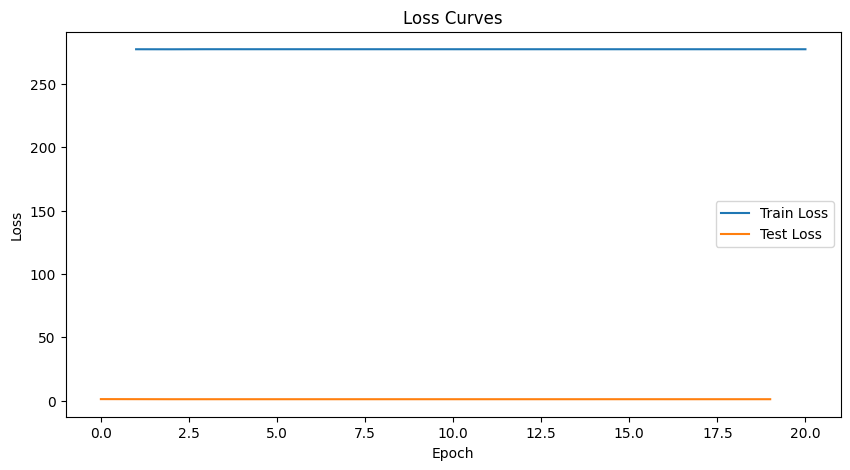

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

In [ ]:
test_dataset.experiments

MultiIndex([('U13', 'E01'),
            ('U13', 'E02'),
            ('U13', 'E03'),
            ('U13', 'E04'),
            ('U13', 'E05'),
            ('U13', 'E06'),
            ('U14', 'E01'),
            ('U14', 'E02'),
            ('U14', 'E03'),
            ('U14', 'E04'),
            ('U14', 'E05'),
            ('U14', 'E06'),
            ('U29', 'E01'),
            ('U29', 'E02'),
            ('U29', 'E03'),
            ('U29', 'E04'),
            ('U29', 'E05'),
            ('U29', 'E06'),
            ('U32', 'E01'),
            ('U32', 'E02'),
            ('U32', 'E03'),
            ('U32', 'E04'),
            ('U32', 'E05'),
            ('U32', 'E06'),
            ('U48', 'E01'),
            ('U48', 'E02'),
            ('U48', 'E03'),
            ('U48', 'E04'),
            ('U48', 'E05'),
            ('U48', 'E06'),
            ('U55', 'E01'),
            ('U55', 'E02'),
            ('U55', 'E03'),
            ('U55', 'E04'),
            ('U55', 'E05'),
            ('U55', 

In [ ]:
pred.shape

torch.Size([1095, 39])

In [ ]:
np.expand_dims(mean, axis=0).shape

(1, 39)

In [ ]:
spline_interp = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_interpolated_merged_data.csv", 
                            usecols=['timestamp', 'user_id', 'emotion'])
end_time = spline_interp.groupby(['user_id', 'emotion']).max()

nn_interpolated_data = []

# Interpolate for each experiment in the test dataset

model.eval()
for experiment in test_dataset.experiments:
    sync_end = end_time.loc[experiment]['timestamp']
    interp_timestamps = np.arange(0, sync_end, step=spf)
    interp_timestamps = torch.tensor(interp_timestamps, dtype=torch.float32)


    input_sequence = test_df.loc[experiment]
    input_sequence, mean, std = process_input_sequence(input_sequence)


    input_sequence = input_sequence.unsqueeze(0)  # Add batch dimension
    interp_timestamps = interp_timestamps.unsqueeze(0)  # Add batch dimension
    
    with torch.no_grad():
        pred = model(input_sequence, interp_timestamps).squeeze(0)  # Remove batch dimension
    pred = (pred.numpy() * np.expand_dims((std + eps), axis=0)) + np.expand_dims(mean, axis=0)  # Denormalize the predictions

    pred = np.concatenate([interp_timestamps.squeeze(0).unsqueeze(-1).numpy(), pred], axis=-1)
    interp_df = pd.DataFrame(pred, columns=test_df.columns)
    user_id, class_key = experiment
    interp_df.insert(0, 'user_id', user_id)
    interp_df.insert(1, 'emotion', class_key)
    nn_interpolated_data.append(interp_df)
    
radar_interp_df = pd.concat(nn_interpolated_data, ignore_index=False)
radar_interp_df.to_csv("E:/CoDaS Project/Radar/C3/radar_nn_test_interpolated_data.csv", index=False)